# Import dependencies

In [1]:
import numpy as np
import pysindy as ps
from pysindy.feature_library.base import BaseFeatureLibrary
from pysindy.utils import AxesArray
from pysindy.feature_library import CustomLibrary
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import savgol_filter


# Helping Functions

In [2]:

def quat_to_euler(quat):
    """
    quat: Nx4 array where each row is [x, y, z, w]
    returns: Nx3 array [roll, pitch, yaw]
    """

    x = quat[:, 0]
    y = quat[:, 1]
    z = quat[:, 2]
    w = quat[:, 3]

    # Roll
    t0 = 2.0 * (w * x + y * z)
    t1 = 1.0 - 2.0 * (x*x + y*y)
    roll = np.arctan2(t0, t1)

    # Pitch
    t2 = 2.0 * (w * y - z * x)
    t2 = np.clip(t2, -1.0, 1.0)
    pitch = np.arcsin(t2)

    # Yaw
    t3 = 2.0 * (w * z + x * y)
    t4 = 1.0 - 2.0 * (y*y + z*z)
    yaw = np.arctan2(t3, t4)

    return np.vstack((roll, pitch, yaw)).T



In [3]:
def running_mean(data, window):
    """
    Running mean for 1D or 2D data.
    Applies filter along axis=0 (time).

    Parameters
    ----------
    data : array-like, shape (N,) or (N, D)
    window : int

    Returns
    -------
    np.ndarray
        Smoothed data
    """
    data = np.asarray(data)

    if window <= 0:
        raise ValueError("window size must be > 0")
    if window > data.shape[0]:
        raise ValueError("window size must be <= number of samples")

    kernel = np.ones(window) / window

    if data.ndim == 1:
        return np.convolve(data, kernel, mode='valid')

    elif data.ndim == 2:
        return np.vstack([
            np.convolve(data[:, i], kernel, mode='valid')
            for i in range(data.shape[1])
        ]).T

    else:
        raise ValueError("data must be 1D or 2D")


In [4]:
def inertial_to_body_velocity(v_ref_inertial, euler):
    """
    Rotate inertial-frame velocity into body frame.

    Parameters
    ----------
    v_ref_inertial : array-like, shape (3,)
        [vx, vy, vz] in inertial frame
    euler : array-like, shape (3,)
        [roll, pitch, yaw] in radians

    Returns
    -------
    v_ref_body : np.ndarray, shape (3,)
        velocity in body frame
    """

    phi, theta, psi = euler

    cphi = np.cos(phi)
    sphi = np.sin(phi)
    cth  = np.cos(theta)
    sth  = np.sin(theta)
    cpsi = np.cos(psi)
    spsi = np.sin(psi)

    # Rotation matrix: inertial → body
    R_bi = np.array([
        [ cth * cpsi,              cth * spsi,             -sth ],
        [ sphi*sth*cpsi - cphi*spsi, sphi*sth*spsi + cphi*cpsi, sphi*cth ],
        [ cphi*sth*cpsi + sphi*spsi, cphi*sth*spsi - sphi*cpsi, cphi*cth ]
    ])

    return R_bi @ v_ref_inertial

def inertial_to_body_velocity_batch(v_ref_inertial, euler):
    """
    Batch conversion inertial → body.

    v_ref_inertial : (N,3)
    euler          : (N,3)

    Returns
    -------
    v_ref_body : (N,3)
    """
    N = v_ref_inertial.shape[0]
    v_body = np.zeros_like(v_ref_inertial)

    for k in range(N):
        v_body[k] = inertial_to_body_velocity(
            v_ref_inertial[k], euler[k]
        )

    return v_body



In [5]:
import numpy as np

def pwm_to_thrust(
    pwm,
    air_density=1.225,        # kg/m^3
    velocity_in=0.0,          # m/s (inflow velocity)
    voltage=16.0,             # V
    voltage_max=16.8,         # V
    pwm_min=1000,
    pwm_max=2000,
    spin_min=0.1,
    spin_max=0.95,
    mot_expo=0.65,
    effective_prop_area=0.02, # m^2
    max_outflow_velocity=25.0 # m/s
):
    """
    ArduPilot SITL motor + propeller thrust model
    Returns thrust in Newtons
    """

    # ----------------------------
    # PWM → normalized command
    # ----------------------------
    pwm_thrust_min = pwm_min + spin_min * (pwm_max - pwm_min)
    pwm_thrust_max = pwm_min + spin_max * (pwm_max - pwm_min)

    command = (pwm - pwm_thrust_min) / (pwm_thrust_max - pwm_thrust_min)
    command = np.clip(command, 0.0, 1.0)

    # ----------------------------
    # Voltage scaling
    # ----------------------------
    voltage_scale = voltage / voltage_max
    if voltage_scale < 0.1:
        return 0.0

    # ----------------------------
    # Command → outflow velocity
    # ----------------------------
    velocity_out = (
        voltage_scale
        * max_outflow_velocity
        * np.sqrt((1 - mot_expo) * command + mot_expo * command**2)
    )

    # ----------------------------
    # Momentum theory thrust
    # ----------------------------
    thrust = 0.5 * air_density * effective_prop_area * (
        velocity_out**2 - velocity_in**2
    )

    return np.maximum(thrust, 0.0)


# Load Data

In [6]:
from pathlib import Path

data_files = sorted(Path('DATA').glob('schroeder_raw*.csv'))
if not data_files:
    raise FileNotFoundError('No schroeder_raw*.csv files found in DATA/')

df = pd.read_csv('DATA/traj_multi.csv')

# df = pd.read_csv('DATA/schroeder_raw_20260124_234551_SI.csv')
pwm_values = df[['m1', 'm2', 'm3', 'm4']].to_numpy()
T_i = pwm_to_thrust(pwm_values)
# Angular rates: prefer rad/s columns if available
if all(c in df.columns for c in ['wx_radps', 'wy_radps', 'wz_radps']):
    ang_vel = df[['wx_radps', 'wy_radps', 'wz_radps']].to_numpy()
else:
    ang_vel = np.deg2rad(df[['wx_raw', 'wy_raw', 'wz_raw']].to_numpy())

quats = df[['qx', 'qy', 'qz', 'qw']].to_numpy()
euler =  quat_to_euler(quats)
# Body-frame velocities from logs
vel = df[['vx_body', 'vy_body', 'vz_body']].to_numpy()
pose = df[['x', 'y', 'z']].to_numpy()
pose_ref = df[['sp_x', 'sp_y', 'sp_z']].to_numpy()

T_N = np.sum(T_i, axis=1)  # total thrust
# Optional placeholders (not used downstream)

comp = 5
start = 65
end = np.size(vel,0)-500

# v_ref = inertial_to_body_velocity_batch(v_ref, euler)
# vel = inertial_to_body_velocity_batch(vel, euler)
SM_W = 20  # smoothing window size
vel = running_mean(vel, window=SM_W)
ang_vel = running_mean(ang_vel, window=SM_W)
euler = running_mean(euler, window=SM_W)
pose = running_mean(pose, window=SM_W)
pose_ref = running_mean(pose_ref, window=SM_W)
T_N = running_mean(T_N, window=SM_W)

# after reading df
t_s = df["t_row_msg"].to_numpy()
dt = float(np.median(np.diff(t_s)))  # robust to small jitter



euler = euler[start:end,:]
vel = vel[start:end,:]
ang_vel = ang_vel[start:end,:]
T_N = T_N[start:end]
pose = pose[start:end,:]
pose_ref = pose_ref[start:end,:]    
# v_ref = v_ref[start:end,:]
np.shape(euler)


window_length = 5  # must be odd and < N
polyorder = 2

udot = savgol_filter(vel[:,0], window_length=window_length, polyorder=polyorder, deriv=1, delta=dt)
vdot = savgol_filter(vel[:,1], window_length=window_length, polyorder=polyorder, deriv=1, delta=dt)
wdot = savgol_filter(vel[:,2], window_length=window_length, polyorder=polyorder, deriv=1, delta=dt)
pdot = savgol_filter(ang_vel[:,0], window_length=window_length, polyorder=polyorder, deriv=1, delta=dt)
qdot = savgol_filter(ang_vel[:,1], window_length=window_length, polyorder=polyorder, deriv=1, delta=dt)
rdot = savgol_filter(ang_vel[:,2], window_length=window_length, polyorder=polyorder, deriv=1, delta=dt)
# Map logged torques to tau_* names used downstream

# error = np.abs(pose_ref - pose)
error = pose_ref - pose

print(vel.shape[0])
u_known = ang_vel[:,2] *vel[:,1] - ang_vel[:,1]*vel[:,2] - 9.81 * np.sin(euler[:,1])
v_known = ang_vel[:,0] *vel[:,2] - ang_vel[:,2]*vel[:,0] - 9.81 * np.sin(euler[:,0])*np.cos(euler[:,1])
w_known = ang_vel[:,1] *vel[:,0] - ang_vel[:,0]*vel[:,1] + (T_N/1.5) - 9.81*np.cos(euler[:,1])*np.cos(euler[:,0]) # not modeled here

U_fit = udot - u_known 
V_fit = vdot - v_known
W_fit = wdot - w_known

X = np.column_stack((U_fit, V_fit, W_fit))

u = vel[:,0]
v = vel[:,1]
w = vel[:,2]

ex = error[:,0]
ey = error[:,1]
ez = error[:,2]
phi = euler[:,0]
theta = euler[:,1]

ones = np.ones_like(ex)

U_combined = np.column_stack((T_N,theta,phi))




2706


[[ 0.02085862  0.02147449  3.27846055]
 [ 0.02169315  0.02172027  3.3099992 ]
 [ 0.02351929  0.02186461  3.3353815 ]
 ...
 [-0.01316818 -0.00730907  3.00383258]
 [-0.01037927 -0.00625585  3.00369867]
 [-0.00689057 -0.00462855  3.00352745]]


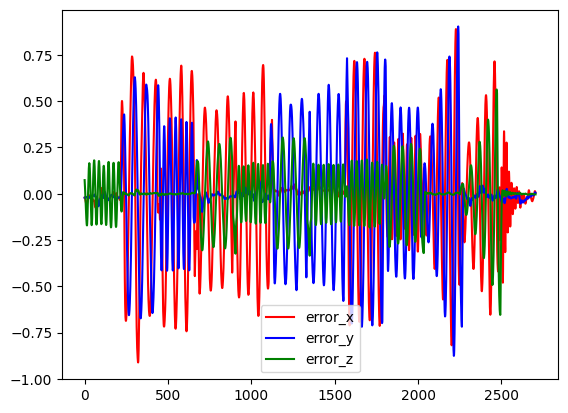

In [7]:
np.shape(T_N)
# np.shape(vel)
print(pose)
plt.plot(error[:,0],color ='red')
plt.plot(error[:,1],color ='blue')
plt.plot(error[:,2],color ='green')
plt.legend(['error_x','error_y','error_z'])
# plt.xlim(18000,20000)

[[ 0.02085862  0.02147449  3.27846055]
 [ 0.02169315  0.02172027  3.3099992 ]
 [ 0.02351929  0.02186461  3.3353815 ]
 ...
 [-0.01316818 -0.00730907  3.00383258]
 [-0.01037927 -0.00625585  3.00369867]
 [-0.00689057 -0.00462855  3.00352745]]


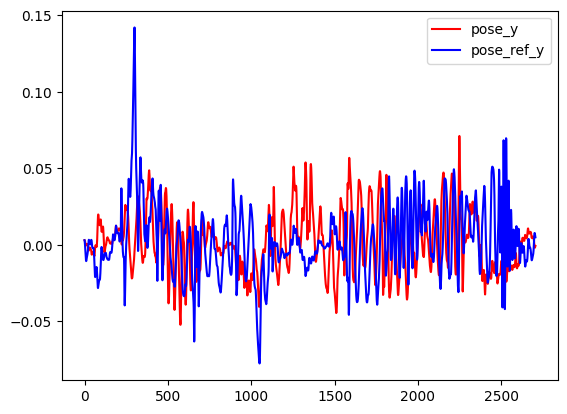

In [33]:
np.shape(T_N)
# np.shape(vel)
print(pose)
plt.plot(euler[:,0],color ='red')
plt.plot(euler[:,1],color ='blue')
# plt.plot(error[:,2],color ='green')
plt.legend(['pose_y','pose_ref_y','pose_ref_y'])
# plt.xlim(18000,20000)

## Visualize Data

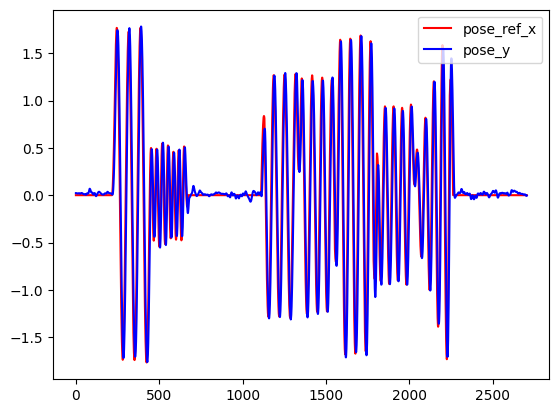

In [8]:

plt.plot(pose_ref[:,1],color ='red')
# plt.plot(yaw_rate_ref,color ='black')
# plt.plot(v_ref[:,2],color ='orange')
plt.plot(pose[:,1],color ='blue')
# plt.plot(ang_vel[:,2],color ='magenta')
# plt.plot(vel[:,2],color ='green')
plt.legend(['pose_ref_x','pose_y','pose_z','pose_x','pose_y','pose_z'])
# plt.xlim(18000,20000)

# SIndy Formulation Main

In [ ]:

# --------------------------
# LINEAR TERMS
# --------------------------

bias_funcs = [lambda : 1.0]
bias_names = [lambda : "1"]



linear_funcs = [
    lambda u: u
]
linear_names = [lambda u: ""+u+""]

# --------------------------
# TRIG TERMS
# --------------------------
trig_funcs = [
    #lambda theta: np.sin(theta),
    #lambda phi: np.cos(phi),
    lambda phi,theta: np.cos(phi)*np.cos(theta),
    lambda phi,theta: np.sin(phi)*np.cos(theta)
]
trig_names = [#lambda phi: "sin(" + phi +")",
     #         lambda phi: "cos(" + phi + ")",
              lambda phi,theta: "cos(" + phi + ")" + "*" + "cos(" + theta + ")",
              lambda phi,theta: "sin(" + phi + ")" + "*" + "cos(" + theta + ")"]
trig_funcs2 = [
    lambda T,theta: T * np.sin(theta),
]
trig_names2 = [lambda T,theta:"(" + T + ")" + "*" + "sin(" + theta +")",
     ]

trig_funcs3 = [
    lambda T,theta: T * np.cos(theta),
]
trig_names3 = [lambda T,theta:"(" + T + ")" + "*" + "cos(" + theta +")",
     ]
# --------------------------
# QUADRATIC TERMS
# --------------------------
quad_funcs = [lambda u: u*u]
quad_names = [lambda u: "( " + u + " * " + u + ")"]
# --------------------------
# HARMONIC TERMS IN alpha
# --------------------------
harm = 0.01
harmonic_funcs = [lambda alpha: np.sin(harm*alpha),
                  lambda alpha: np.sin(2*harm*alpha),
                  lambda alpha: np.sin(3*harm*alpha)]
harmonic_names = [lambda alpha: "sin( 1 " + alpha + ")",
                  lambda alpha: "sin( 2 " + alpha + ")",
                   lambda alpha: "sin( 3 " + alpha + ")"]

# --------------------------
# Summation of thrusts
# --------------------------
sum_funcs = [lambda T1,T2,T3,T4: T1 + T2 +T3 +T4]
sum_names = [lambda T1,T2,T3,T4: "(" + T1 + " + " + T2 + " + " + T3 +  " + " + T4 + ")"]

sum_funcs2 = [lambda T1,T2: T1 + T2]
sum_names2 = [lambda T1,T2: "(" + T1 + " + " + T2 + ")"]

# --------------------------
# T + trgnometric terms
# --------------------------

T_trig_funcs = [
    lambda T,phi,theta: T * np.cos(phi)*np.cos(theta),
    lambda T,phi,theta: T * np.sin(phi)*np.cos(theta)
]
T_trig_names = [lambda T,phi,theta: "T * cos(" + phi + ")" + "*" + "cos(" + theta + ")",
              lambda T,phi,theta: "T * sin(" + phi + ")" + "*" + "cos(" + theta + ")",]
# U_combined columns are: [ones, ex, ey, ez, phi, theta]

# U_combined = np.column_stack((ones, u, v, w))

# indices into U_combined (0..5)
IDX_ONE   = 0
IDX_ERR_X = 1
IDX_ERR_Y = 2
IDX_ERR_Z = 3
IDX_u   = 4
IDX_v = 5
IDX_w = 6
# --------------------------
# LIBRARIES
# --------------------------
custom_lib1 = ps.CustomLibrary(bias_funcs, bias_names)      # lambda: 1.0  (no inputs!)
custom_lib2 = ps.CustomLibrary(linear_funcs, linear_names)  # err_x
custom_lib3 = ps.CustomLibrary(linear_funcs, linear_names)  # err_y
custom_lib4 = ps.CustomLibrary(trig_funcs2, trig_names2)  # err_z
custom_lib5 = ps.CustomLibrary(trig_funcs3, trig_names3)  # err_z
custom_lib6 = ps.CustomLibrary(trig_funcs2, trig_names2)  # err_z
custom_lib7 = ps.CustomLibrary(trig_funcs3, trig_names3)  # err_z

inputs_per_library = [
    [],                # bias library takes NO inputs
    [1],       # linear on u
    [2],       # linear on v
    [0,1],       # linear on w
    [0,1],         # quad on u
    [0,2],       # quad on v
    [0,2],      # quad on w
]

generalized_lib = ps.GeneralizedLibrary(
    libraries=[custom_lib1, custom_lib2, custom_lib3, custom_lib4, custom_lib5, custom_lib6, custom_lib7],
    inputs_per_library=inputs_per_library
)

optimizer = ps.STLSQ(threshold=0.02, unbias=True)

model = ps.SINDy(
    feature_library=generalized_lib,
    optimizer=optimizer,
    differentiation_method=ps.SmoothedFiniteDifference()
)

model.fit(
    X,
    u=U_combined,
    t=dt,
    feature_names=['T_N','theta','phi']  #  correspond to U_combined columns
)

model.print(lhs=["dfx", "dfy", "dfz"])
print(model.get_feature_names())


dfx = 0.236 1 + 0.026 theta + -0.092 phi + 0.038 (T_N)*sin(theta) + -0.030 (T_N)*cos(phi)
dfy = -0.057 (T_N)*sin(theta)
dfz = 0.102 1 + -0.039 phi + -0.103 (T_N)*sin(theta) + 0.161 (T_N)*cos(theta) + -0.069 (T_N)*sin(phi) + 0.120 (T_N)*cos(phi)
['1', 'theta', 'phi', '(T_N)*sin(theta)', '(T_N)*cos(theta)', '(T_N)*sin(phi)', '(T_N)*cos(phi)']


In [11]:

# optimizer = ps.ConstrainedSR3(reg_weight_lam=0.009,regularizer='L0',constraint_lhs=None, relax_coeff_nu=1.0)
optimizer = ps.SR3(reg_weight_lam=0.001,regularizer='L0', relax_coeff_nu=1.0)
# optimizer = ps.STLSQ(threshold=0.02,unbias = True)
model = ps.SINDy(feature_library=generalized_lib,optimizer = optimizer,
                 differentiation_method = ps.SmoothedFiniteDifference())
model.fit(X,u= U_combined,t=dt,
          feature_names=['T_N','theta','phi']
          )
model.print(lhs=["dfx", "dfy", "dfz"])
model.get_feature_names()

dfx = 0.238 1 + -0.092 phi
dfy = -0.053 (T_N)*sin(theta)
dfz = 0.099 1 + -0.102 (T_N)*sin(theta) + 0.160 (T_N)*cos(theta) + -0.068 (T_N)*sin(phi) + 0.119 (T_N)*cos(phi)


['1',
 'theta',
 'phi',
 '(T_N)*sin(theta)',
 '(T_N)*cos(theta)',
 '(T_N)*sin(phi)',
 '(T_N)*cos(phi)']

# STLSQ Fitting

In [12]:
import numpy as np

# Build Theta matrix (N x 7) from your signals
T = T_N                      # or T_acc = T_N / mass_kg (recommended if T_N is Newtons)
th = theta
ph = phi

Theta = np.column_stack([
    np.ones_like(T),         # 1
    th,                      # theta
    ph,                      # phi
    T*np.sin(th),            # T*sin(theta)
    T*np.cos(th),            # T*cos(theta)
    T*np.sin(ph),            # T*sin(phi)
    T*np.cos(ph),            # T*cos(phi)
])

Y = X   # X is your (N x 3) residual accel target: [U_fit, V_fit, W_fit]

def stlsq(Theta, Y, thresh=0.02, iters=10):
    """
    Sequential Thresholded Least Squares for multi-output Y (N x 3).
    Returns A (7 x 3).
    """
    A = np.linalg.lstsq(Theta, Y, rcond=None)[0]  # (7 x 3)
    for _ in range(iters):
        small = np.abs(A) < thresh
        A[small] = 0.0
        for j in range(Y.shape[1]):
            keep = ~small[:, j]
            if np.any(keep):
                A[keep, j] = np.linalg.lstsq(Theta[:, keep], Y[:, j], rcond=None)[0]
    return A

A_hat = stlsq(Theta, Y, thresh=0.8, iters=10)

feature_names = ["1","theta","phi","T*sin(theta)","T*cos(theta)","T*sin(phi)","T*cos(phi)"]
print("A_hat shape:", A_hat.shape)
for j, out in enumerate(["ax_res","ay_res","az_res"]):
    print(f"\n{out} = ", end="")
    terms = []
    for i, name in enumerate(feature_names):
        if A_hat[i,j] != 0:
            terms.append(f"{A_hat[i,j]:+.4f}*{name}")
    print(" ".join(terms) if terms else "0")


A_hat shape: (7, 3)

ax_res = -0.8019*1 -34.5554*theta +15.0190*phi +4.5975*T*sin(theta) -1.7061*T*cos(theta) -1.4343*T*sin(phi) +1.7805*T*cos(phi)

ay_res = -10.7747*theta +4.6612*phi +1.0269*T*sin(theta) -1.3044*T*cos(theta) +1.3054*T*cos(phi)

az_res = +2.5830*1 +4.7200*theta +28.9488*phi -2.7088*T*sin(phi)
